# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [4]:
# 设置任务参数
name = "test"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2023-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [6]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [7]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
df

datetime,open,high,low,close,volume,turnover,open_interest,vwap,vt_symbol
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,str
2007-09-24 00:00:00,0.999747,1.061367,0.998354,1.0,1.1576e7,4.4890444e8,0.0,38.778724,"""600331.SSE"""
2007-09-25 00:00:00,0.999621,1.024801,0.943439,0.972289,7.1024e6,2.61277003e8,0.0,36.787122,"""600331.SSE"""
2007-09-26 00:00:00,0.972289,1.016069,0.944071,1.014805,9.9975e6,3.72405502e8,0.0,37.249698,"""600331.SSE"""
2007-09-27 00:00:00,1.014805,1.014805,1.014805,1.014805,0.0,0.0,0.0,NaN,"""600331.SSE"""
2007-09-28 00:00:00,1.014805,1.014805,1.014805,1.014805,0.0,0.0,0.0,NaN,"""600331.SSE"""
…,…,…,…,…,…,…,…,…,…
2024-01-04 00:00:00,1.16251,1.164683,1.153852,1.161429,7.8750e6,7.6799e7,0.0,9.752176,"""000828.SZSE"""
2024-01-05 00:00:00,1.166845,1.176584,1.144113,1.150609,1.4346e7,1.4053e8,0.0,9.795818,"""000828.SZSE"""
2024-01-08 00:00:00,1.14087,1.145193,1.121381,1.121381,1.0844e7,1.0329e8,0.0,9.524687,"""000828.SZSE"""


In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period = ("2008-01-01", "2014-12-31"),
    valid_period = ("2015-01-01", "2016-12-31"),
    test_period = ("2017-01-01", "2020-8-31"),
)

In [10]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

In [11]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [12]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=3)

# 应用数据预处理器
dataset.process_data()

2026-05-12 21:09:42 开始计算表达式因子特征


100%|██████████████████████████████████████████████████████████████████████████████| 159/159 [1:21:14<00:00, 30.65s/it]


2026-05-12 22:30:58 开始合并结果数据因子特征


0it [00:00, ?it/s]


2026-05-12 22:31:01 开始筛选成分股数据


100%|███████████████████████████████████████████████████████████████████████████████| 819/819 [00:06<00:00, 131.16it/s]


Dropped 3.7% entries from factor data: 0.3% in forward returns computation and 3.4% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.861320,0.118430,0.149646,89040,10.000438
2.0,0.001492,0.929111,0.252767,0.195060,89040,10.000438
3.0,0.010163,0.966824,0.326412,0.216531,89040,10.000438
4.0,0.016945,0.992620,0.388163,0.227620,89031,9.999427
5.0,0.025167,1.000000,0.446737,0.232003,89040,10.000438
6.0,0.036461,1.000000,0.506544,0.230762,89019,9.998079
7.0,0.052632,1.000000,0.571592,0.223312,89031,9.999427
8.0,0.073814,1.000000,0.645468,0.207728,89040,10.000438
9.0,0.109371,1.000000,0.735973,0.178921,89040,10.000438


Returns Analysis


,1D,5D,10D
Ann. alpha,0.030,-0.068,-0.021
beta,0.014,0.009,0.020
Mean Period Wise Return Top Quantile (bps),4.847,-4.110,-1.478
Mean Period Wise Return Bottom Quantile (bps),-3.195,0.728,-0.767
Mean Period Wise Spread (bps),8.042,-4.823,-0.670


<Figure size 640x480 with 0 Axes>

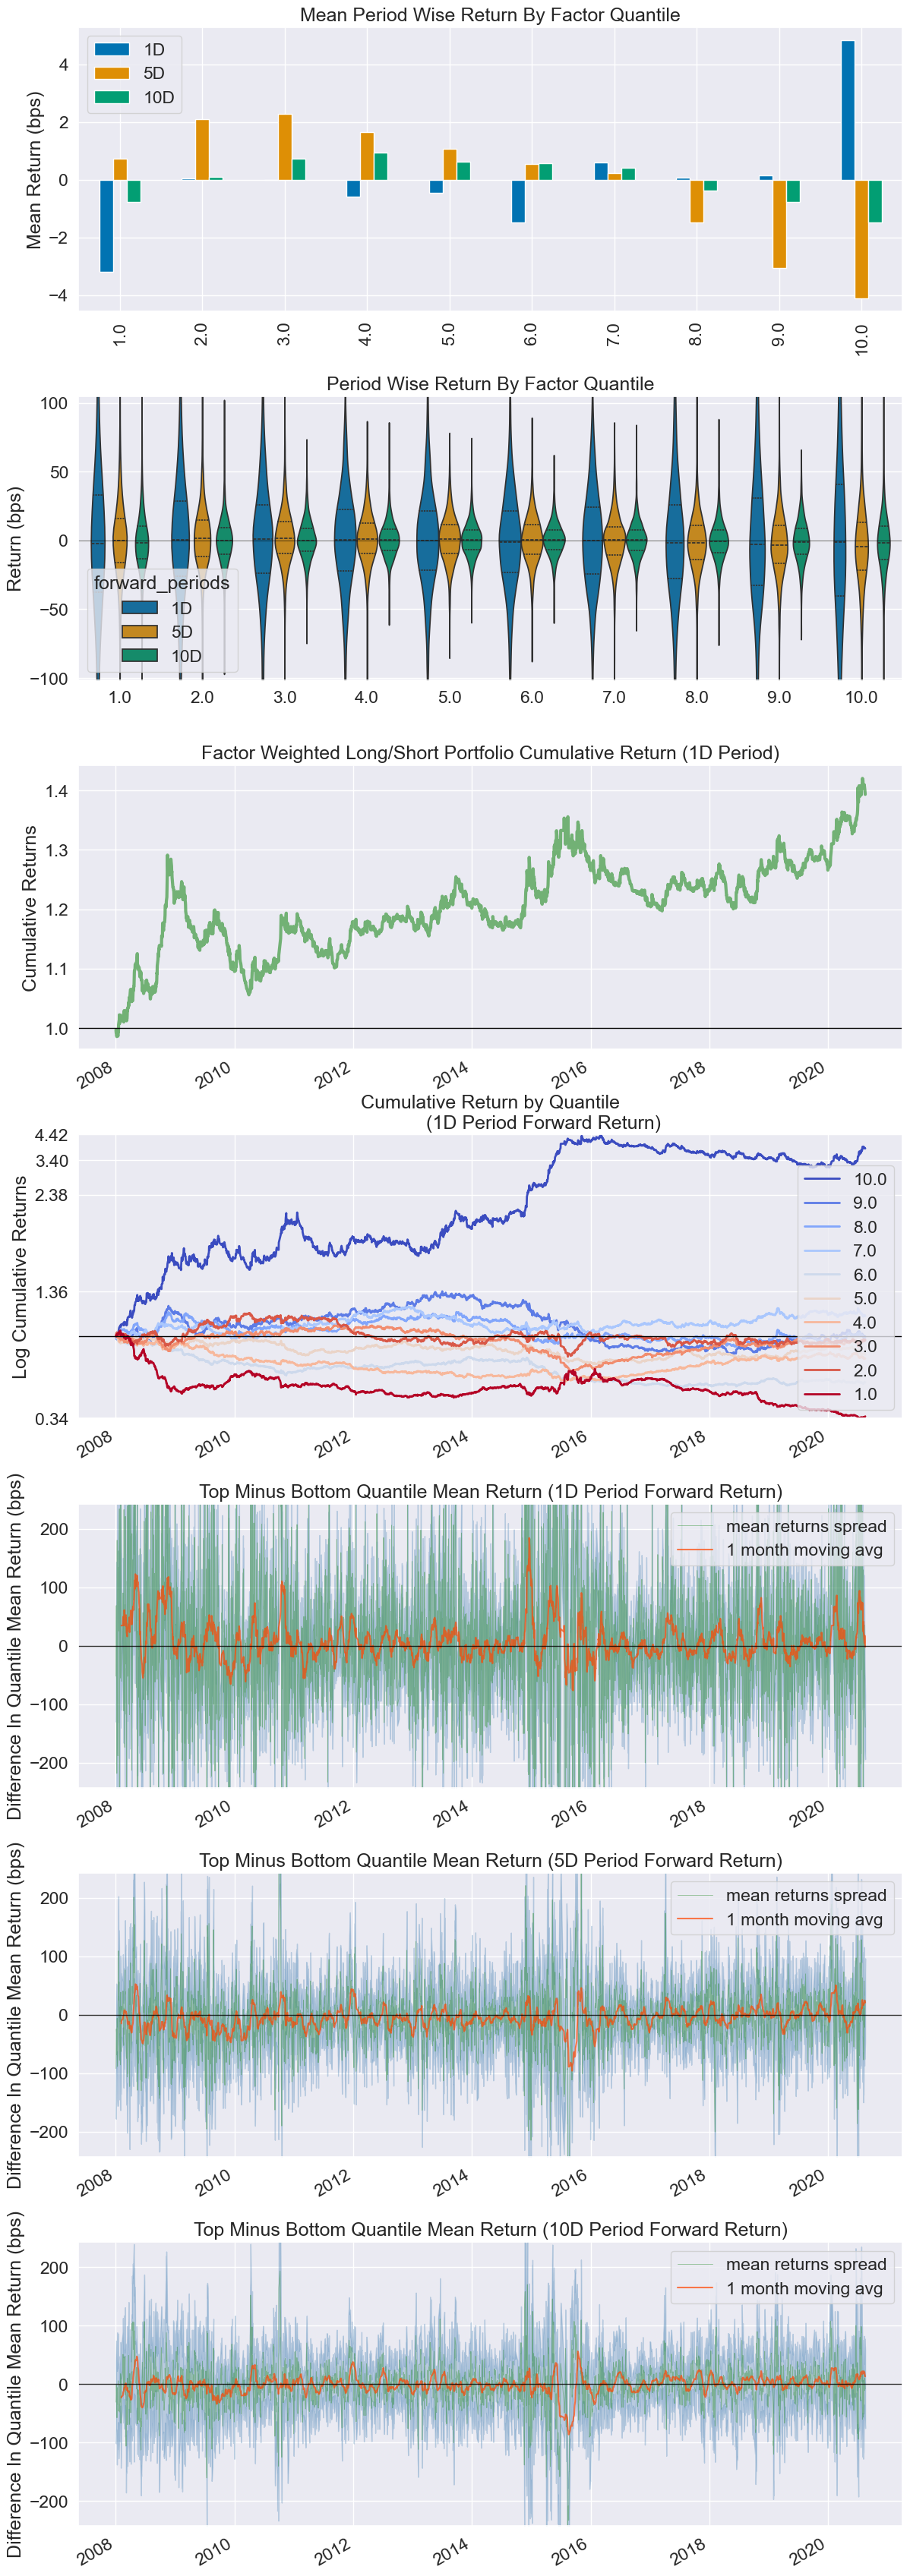

Information Analysis


,1D,5D,10D
IC Mean,-0.034,-0.036,-0.012
IC Std.,0.160,0.150,0.148
Risk-Adjusted IC,-0.214,-0.243,-0.084
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


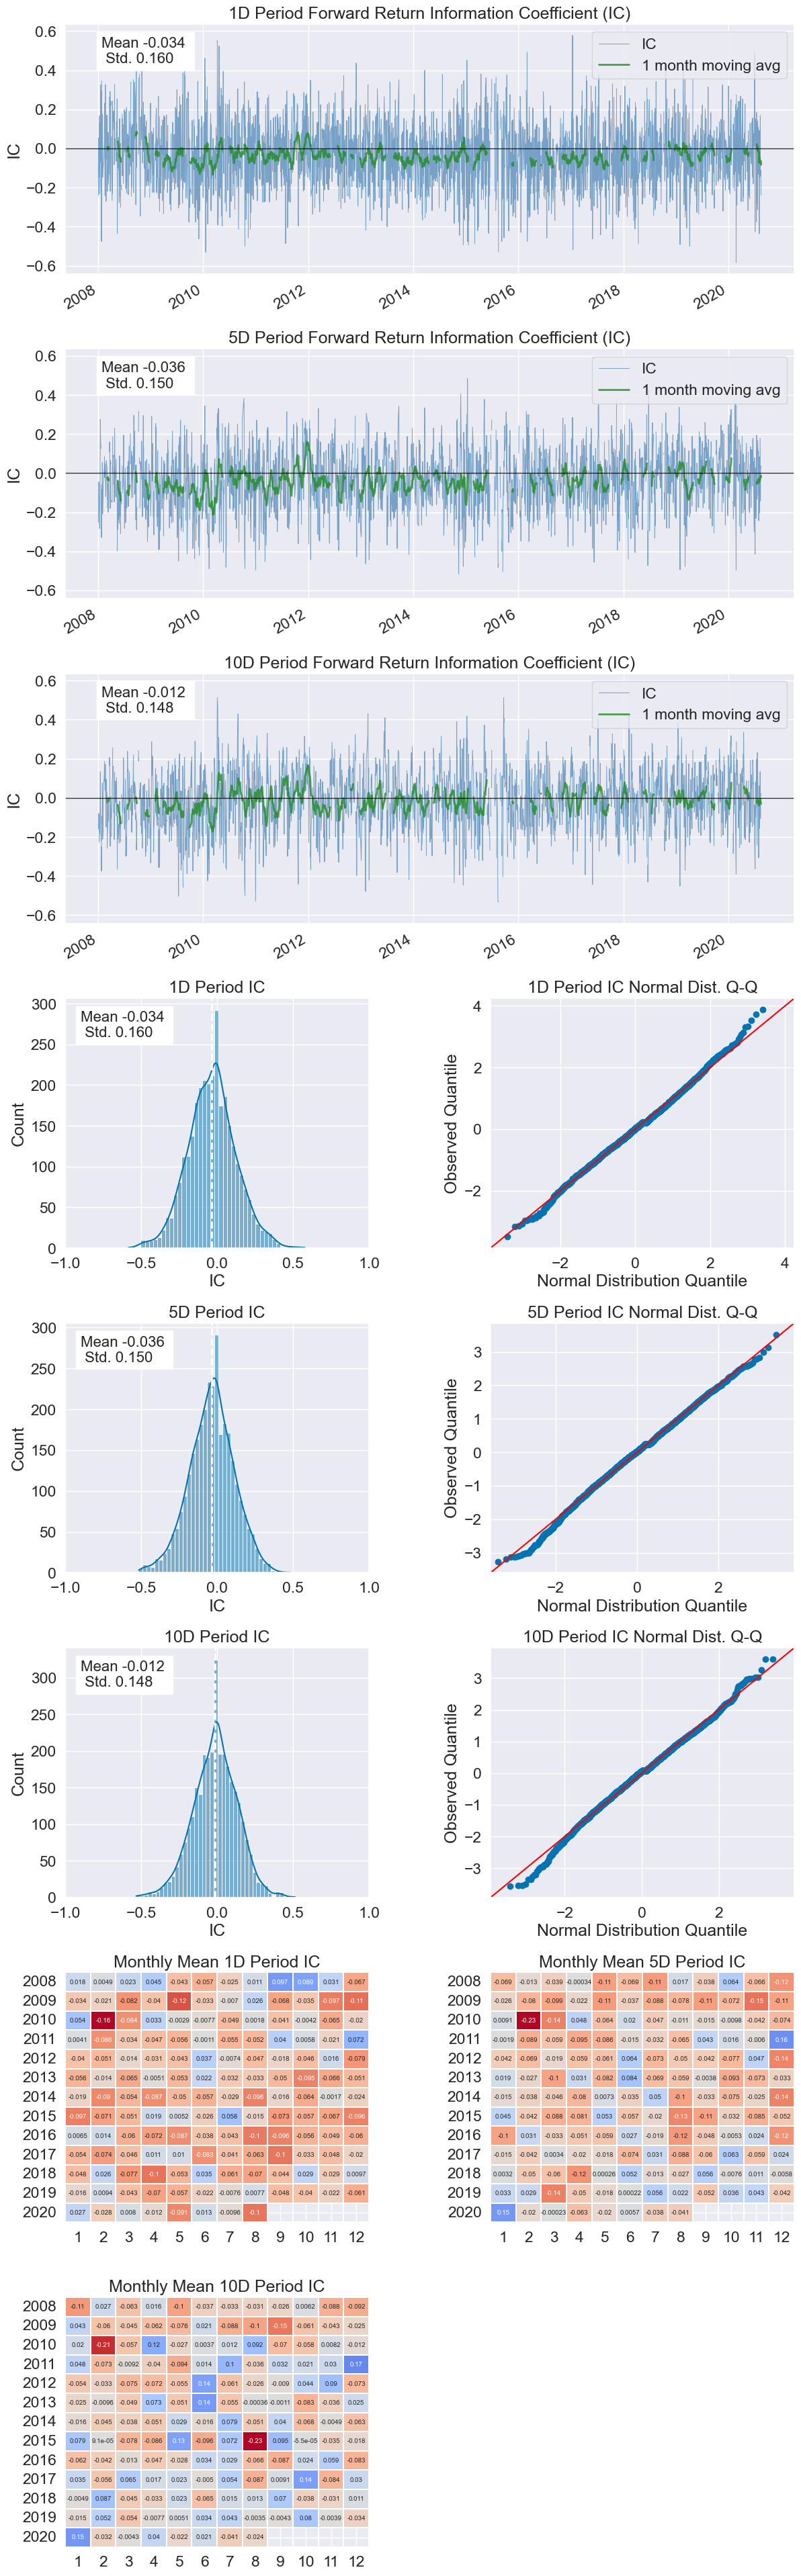

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.533,0.747,0.754
Quantile 2.0 Mean Turnover,0.767,0.905,0.896
Quantile 3.0 Mean Turnover,0.827,0.899,0.896
Quantile 4.0 Mean Turnover,0.850,0.896,0.895
Quantile 5.0 Mean Turnover,0.860,0.896,0.896
Quantile 6.0 Mean Turnover,0.861,0.895,0.896
Quantile 7.0 Mean Turnover,0.856,0.900,0.897
Quantile 8.0 Mean Turnover,0.837,0.900,0.899
Quantile 9.0 Mean Turnover,0.795,0.900,0.894
Quantile 10.0 Mean Turnover,0.674,0.897,0.887


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.583,0.011,0.056


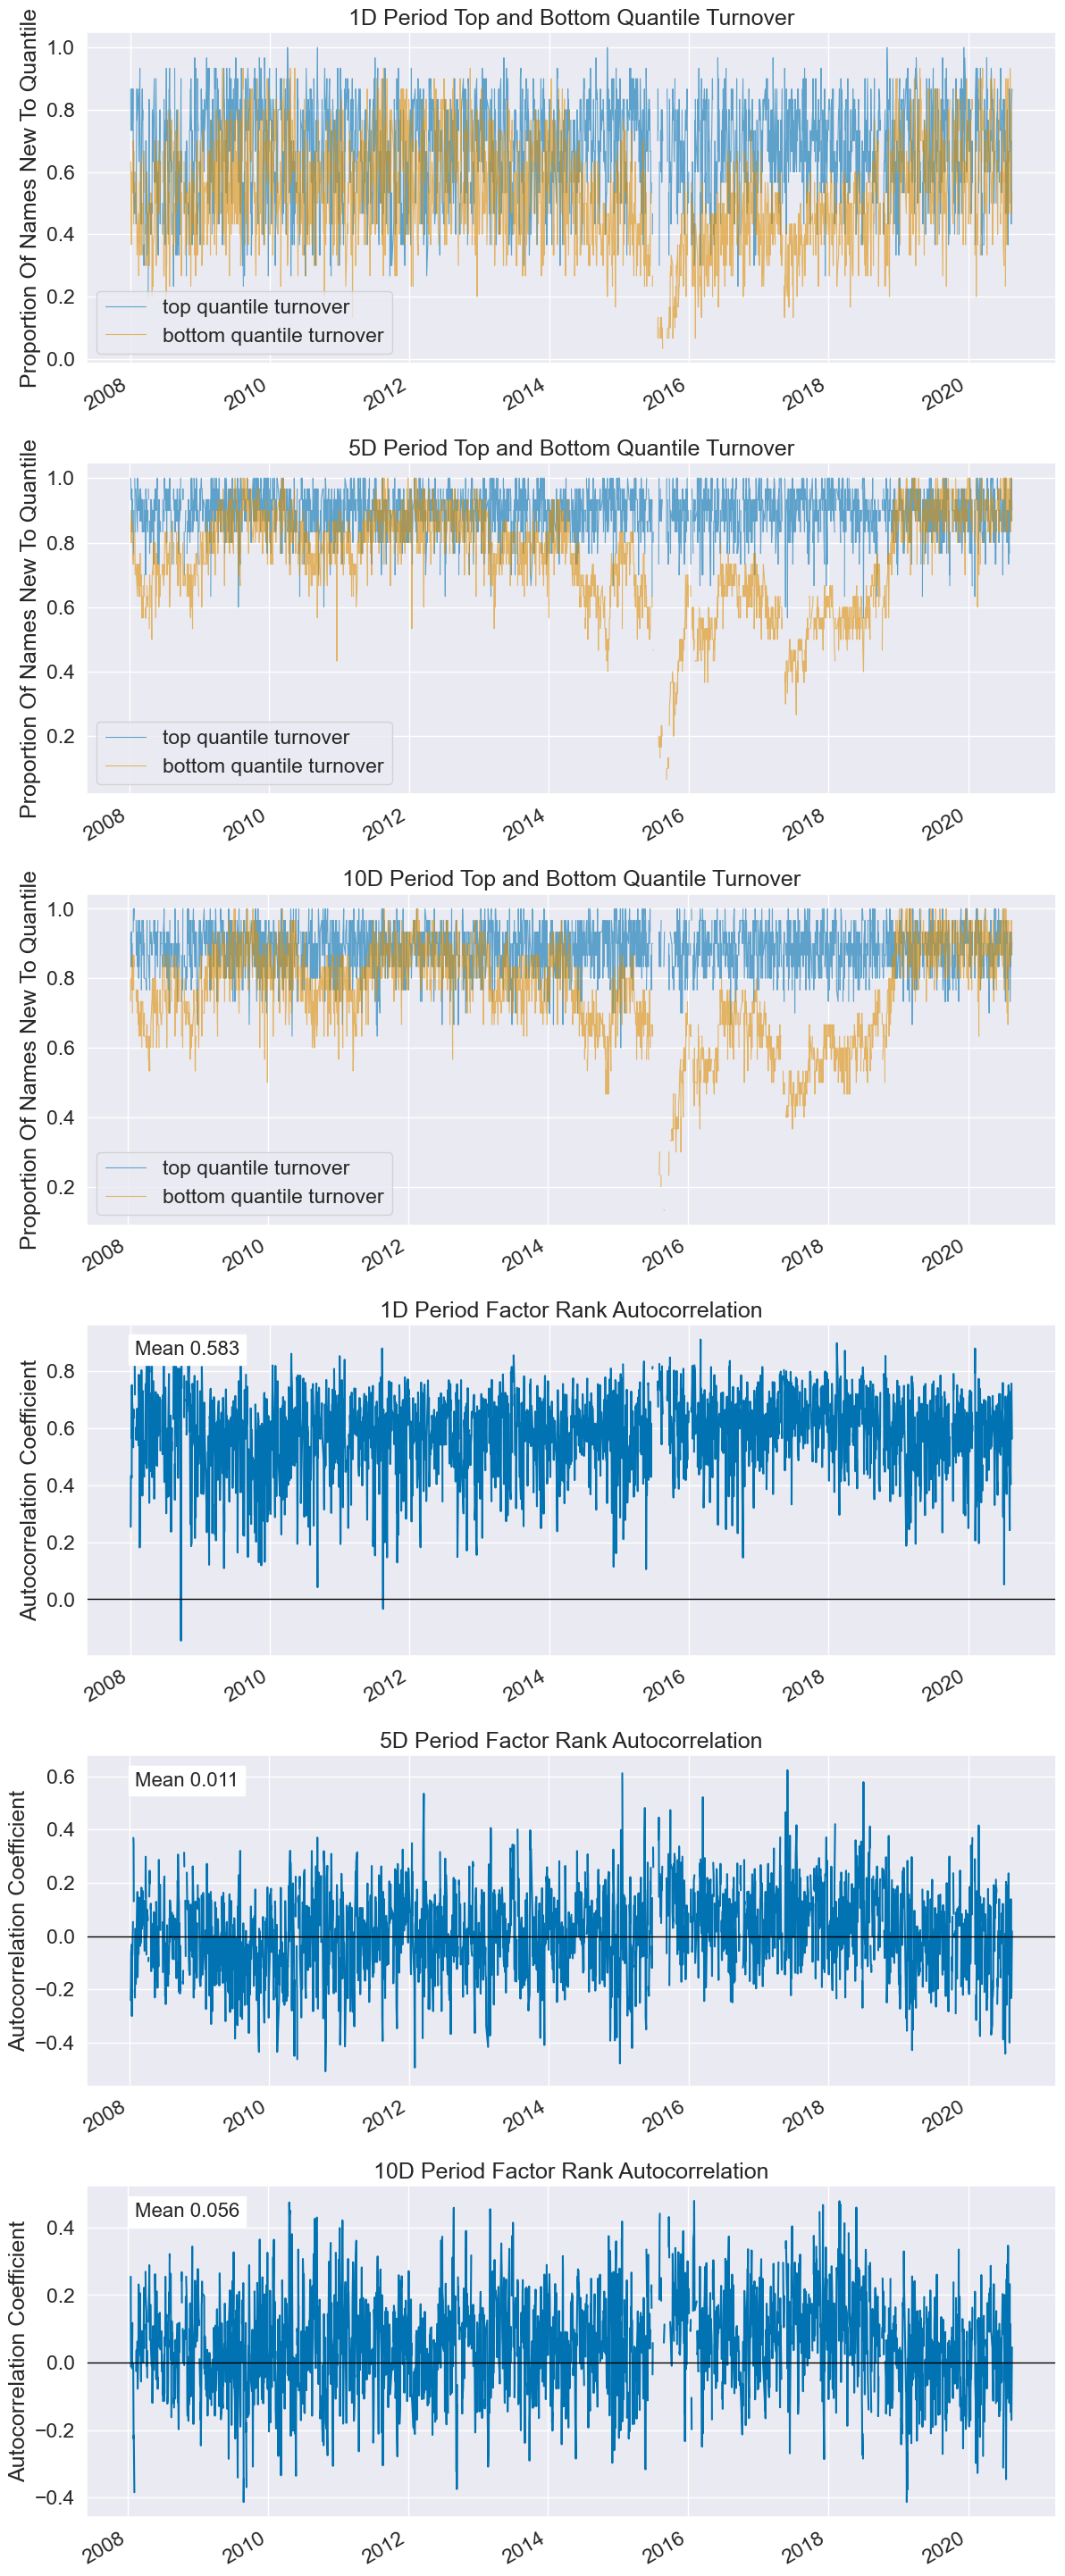

In [13]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [14]:
# 数据预处理
dataset.process_data()

In [16]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [17]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lgb_model import LgbModel

In [18]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [19]:
# 创建模型对象
model: AlphaModel = LgbModel(seed=42)

In [20]:
# 使用数据集训练模型
model.fit(dataset)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32154
[LightGBM] [Info] Number of data points in the train set: 510579, number of used features: 149
[LightGBM] [Info] Start training from score 0.000000
[1]	train's l2: 0.995305	valid's l2: 0.995569
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 0.99408	valid's l2: 0.994614
[3]	train's l2: 0.992872	valid's l2: 0.993941
[4]	train's l2: 0.99184	valid's l2: 0.993274
[5]	train's l2: 0.99094	valid's l2: 0.992589
[6]	train's l2: 0.990069	valid's l2: 0.992087
[7]	train's l2: 0.989291	valid's l2: 0.99182
[8]	train's l2: 0.988562	valid's l2: 0.991373
[9]	train's l2: 0.987838	valid's l2: 0.991249
[10]	train's l2: 0.987203	valid's l2: 0.991171
[11]	train's l2: 0.986551	valid's l2: 0.991027
[12]	train's l2: 0.986022	valid's l2: 0.991017
[13]	train's l2: 0.985479	valid's l2: 0.991

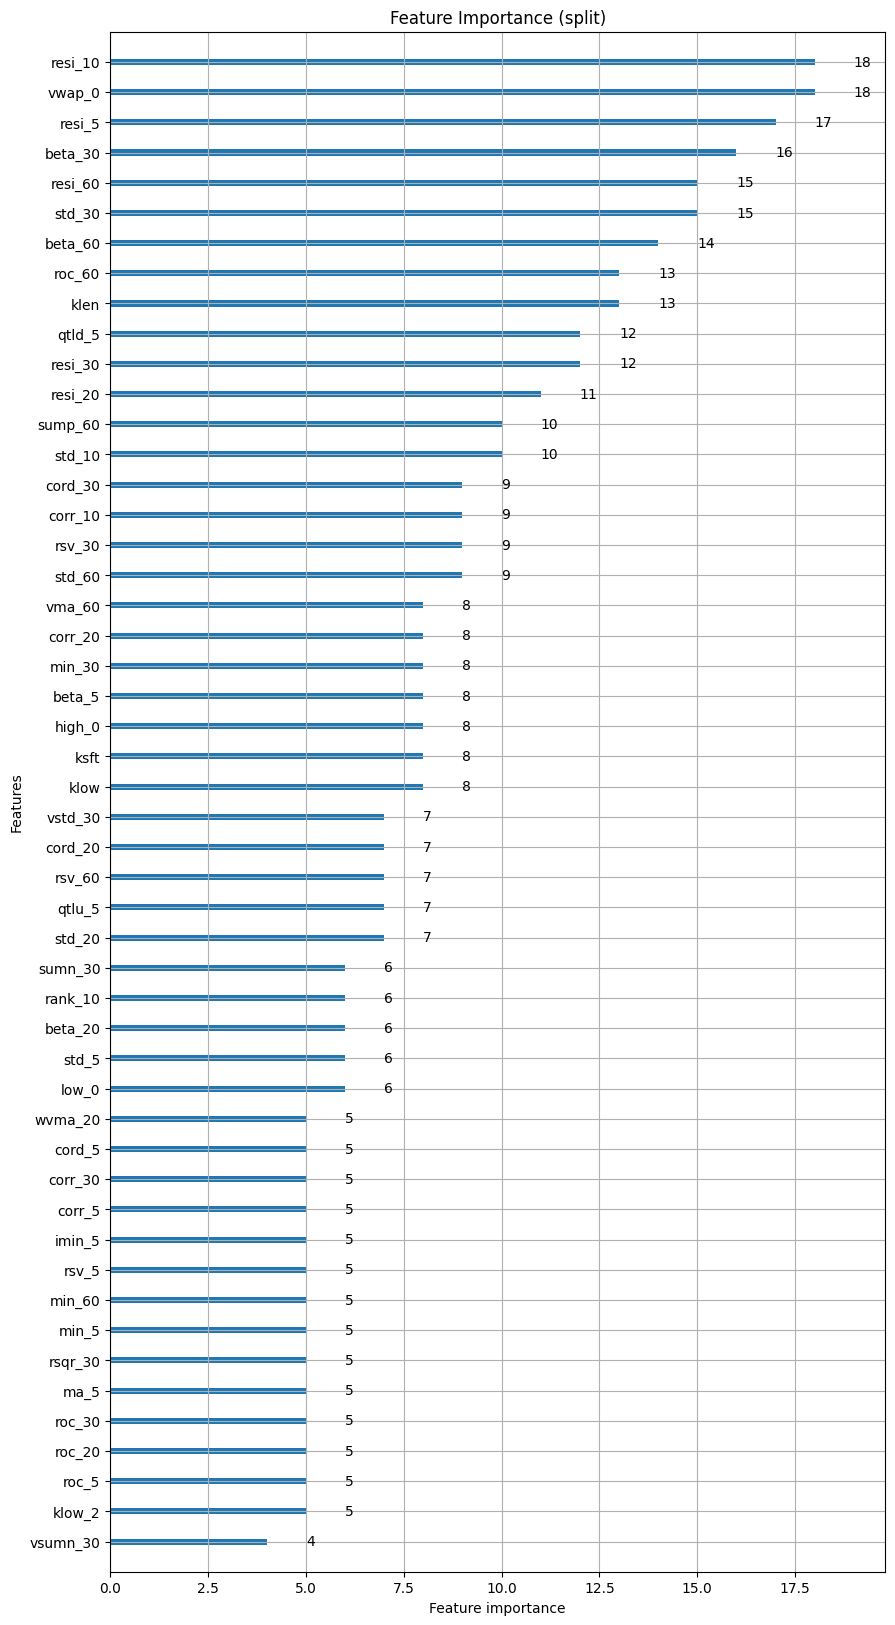

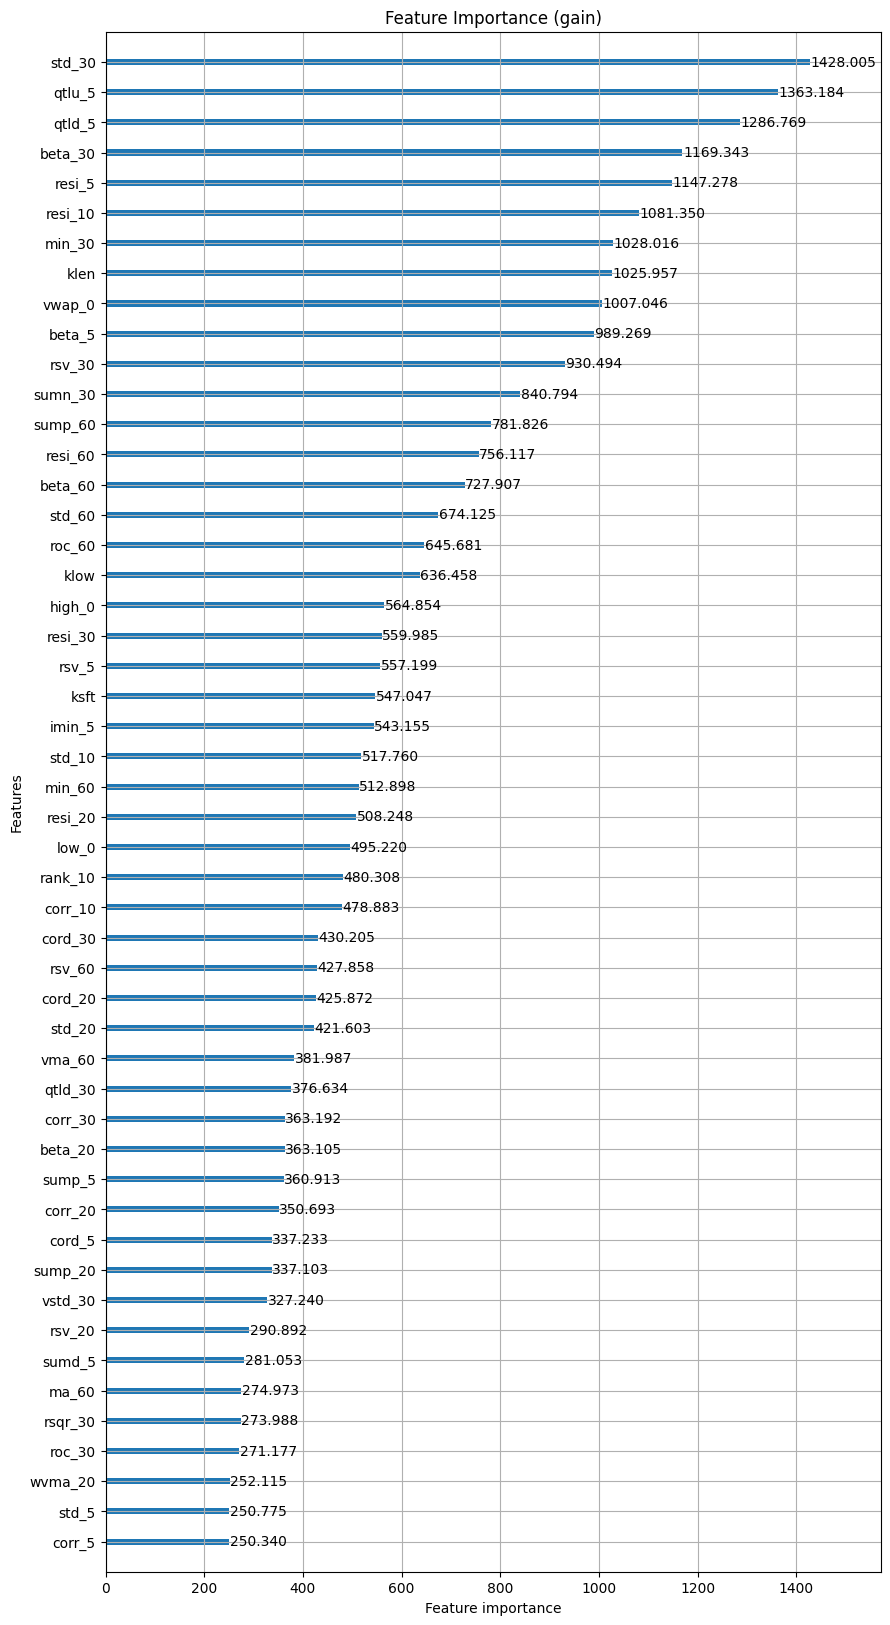

In [21]:
# 查看模型细节
model.detail()

In [22]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [23]:
model: AlphaModel = lab.load_model(name)

In [24]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-3.132407,0.016979,-0.087792,0.097216,26476,10.006047
2,-0.743173,0.050834,-0.045251,0.028642,26472,10.004535
3,-0.600762,0.072115,-0.029298,0.026140,26458,9.999244
4,-0.585278,0.086077,-0.017655,0.025986,26466,10.002268
5,-0.558045,0.108436,-0.007572,0.024522,26500,10.015117
6,-0.377572,0.125156,0.002345,0.021736,26429,9.988284
7,-0.096922,0.142754,0.012877,0.021952,26456,9.998488
8,-0.058968,0.176039,0.025401,0.024328,26436,9.990930
9,-0.036592,0.209732,0.043048,0.027530,26448,9.995465


Returns Analysis


,1D,5D,10D
Ann. alpha,0.845,0.372,0.184
beta,0.036,0.024,0.008
Mean Period Wise Return Top Quantile (bps),19.789,11.313,6.652
Mean Period Wise Return Bottom Quantile (bps),-21.698,-11.520,-5.166
Mean Period Wise Spread (bps),41.487,22.804,11.784


<Figure size 640x480 with 0 Axes>

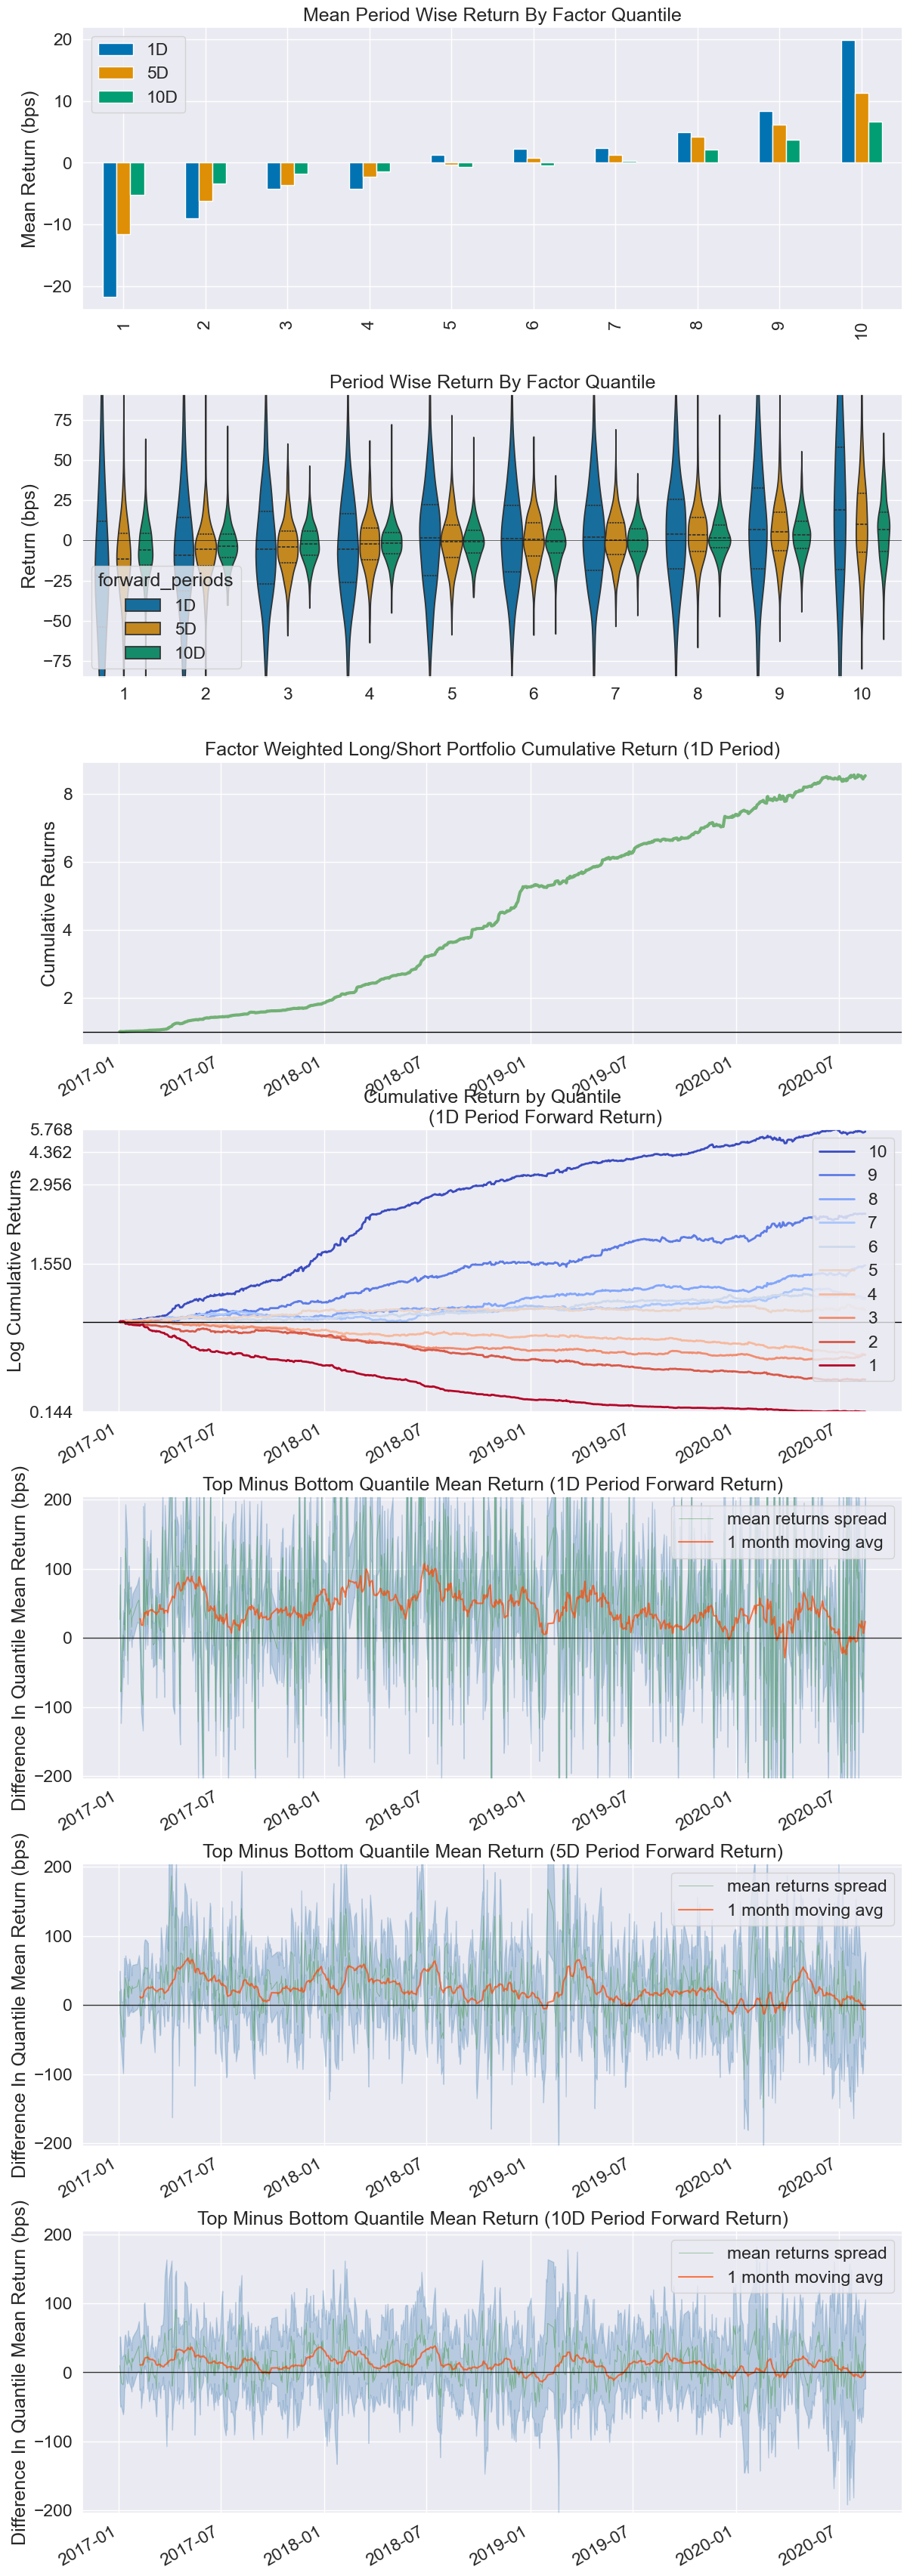

Information Analysis


,1D,5D,10D
IC Mean,0.064,0.073,0.055
IC Std.,0.129,0.125,0.113
Risk-Adjusted IC,0.501,0.586,0.484
t-stat(IC),14.865,17.389,14.362
p-value(IC),0.000,0.000,0.000
IC Skew,0.159,0.162,0.084
IC Kurtosis,0.808,0.063,-0.186


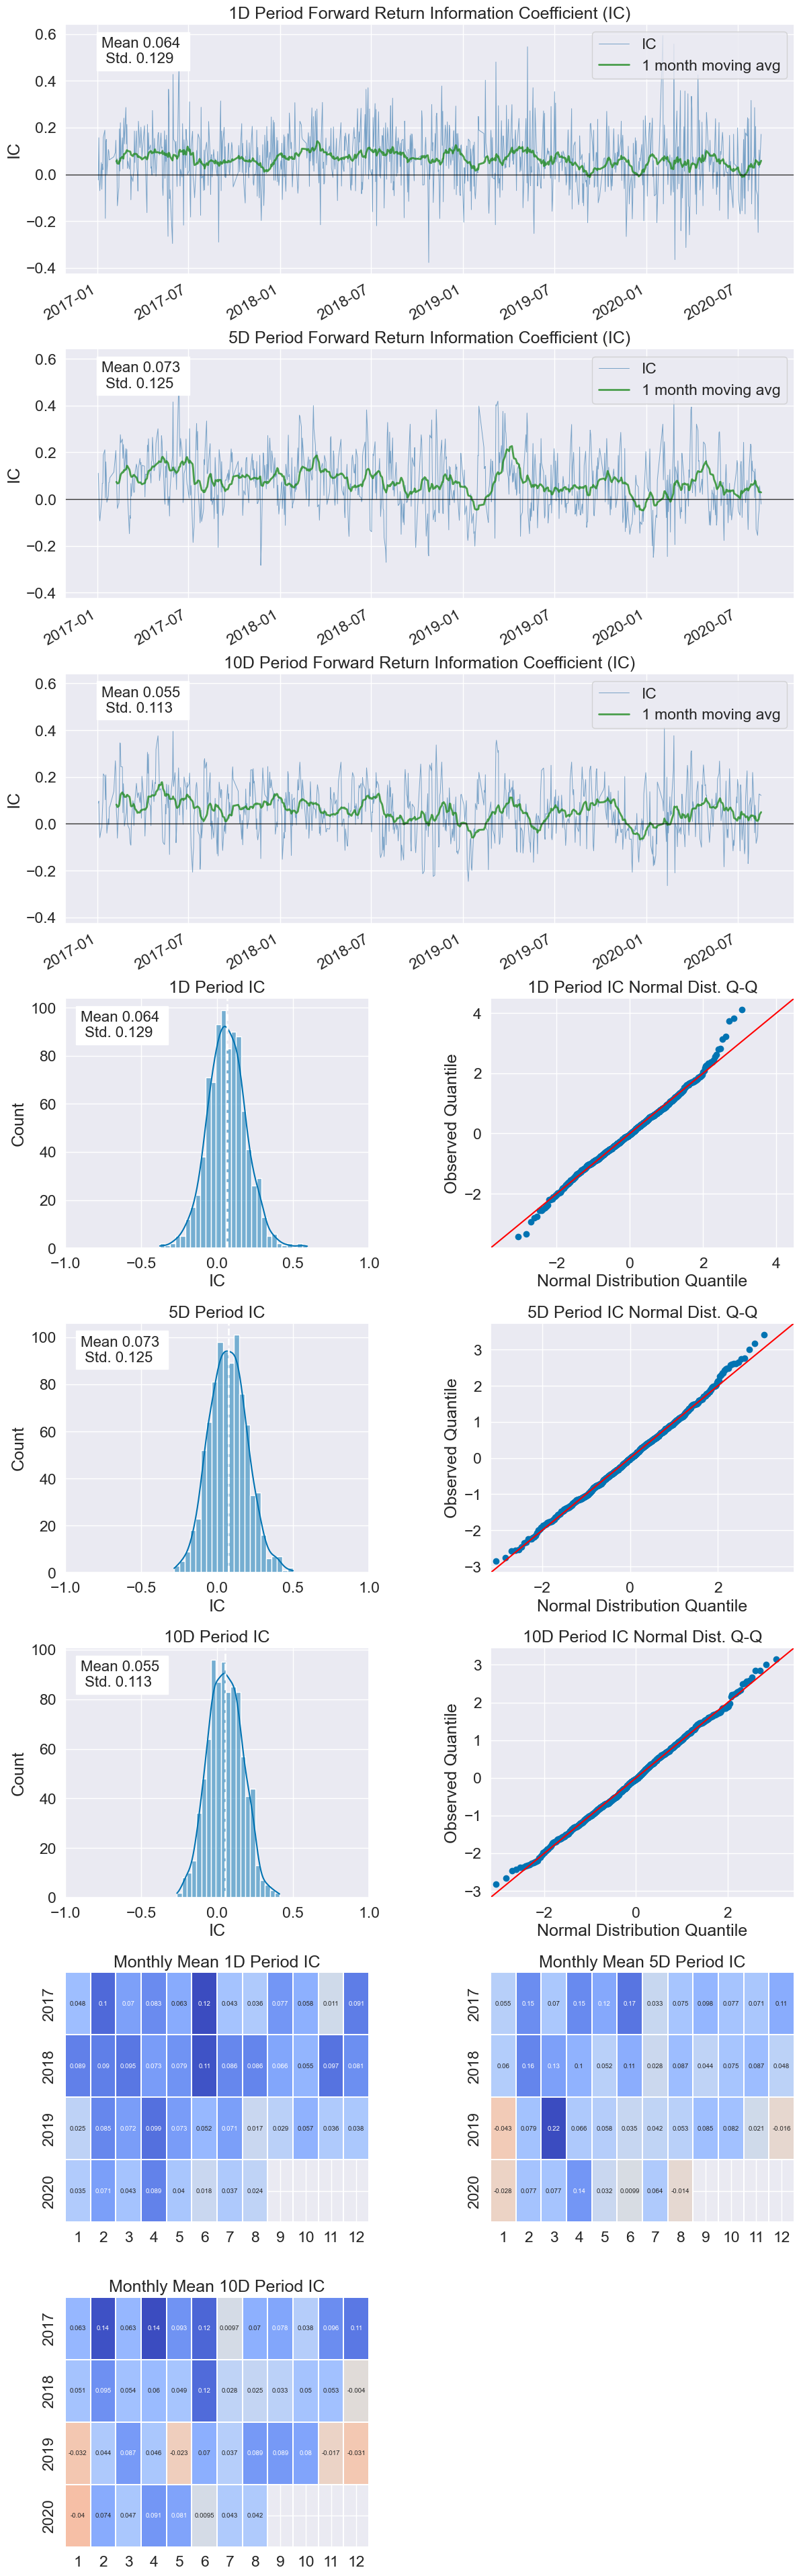

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.577,0.817,0.840
Quantile 2 Mean Turnover,0.765,0.872,0.887
Quantile 3 Mean Turnover,0.812,0.882,0.890
Quantile 4 Mean Turnover,0.827,0.885,0.889
Quantile 5 Mean Turnover,0.828,0.878,0.886
Quantile 6 Mean Turnover,0.824,0.882,0.885
Quantile 7 Mean Turnover,0.822,0.883,0.889
Quantile 8 Mean Turnover,0.802,0.885,0.890
Quantile 9 Mean Turnover,0.751,0.874,0.881
Quantile 10 Mean Turnover,0.515,0.789,0.803


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.563,0.12,0.088


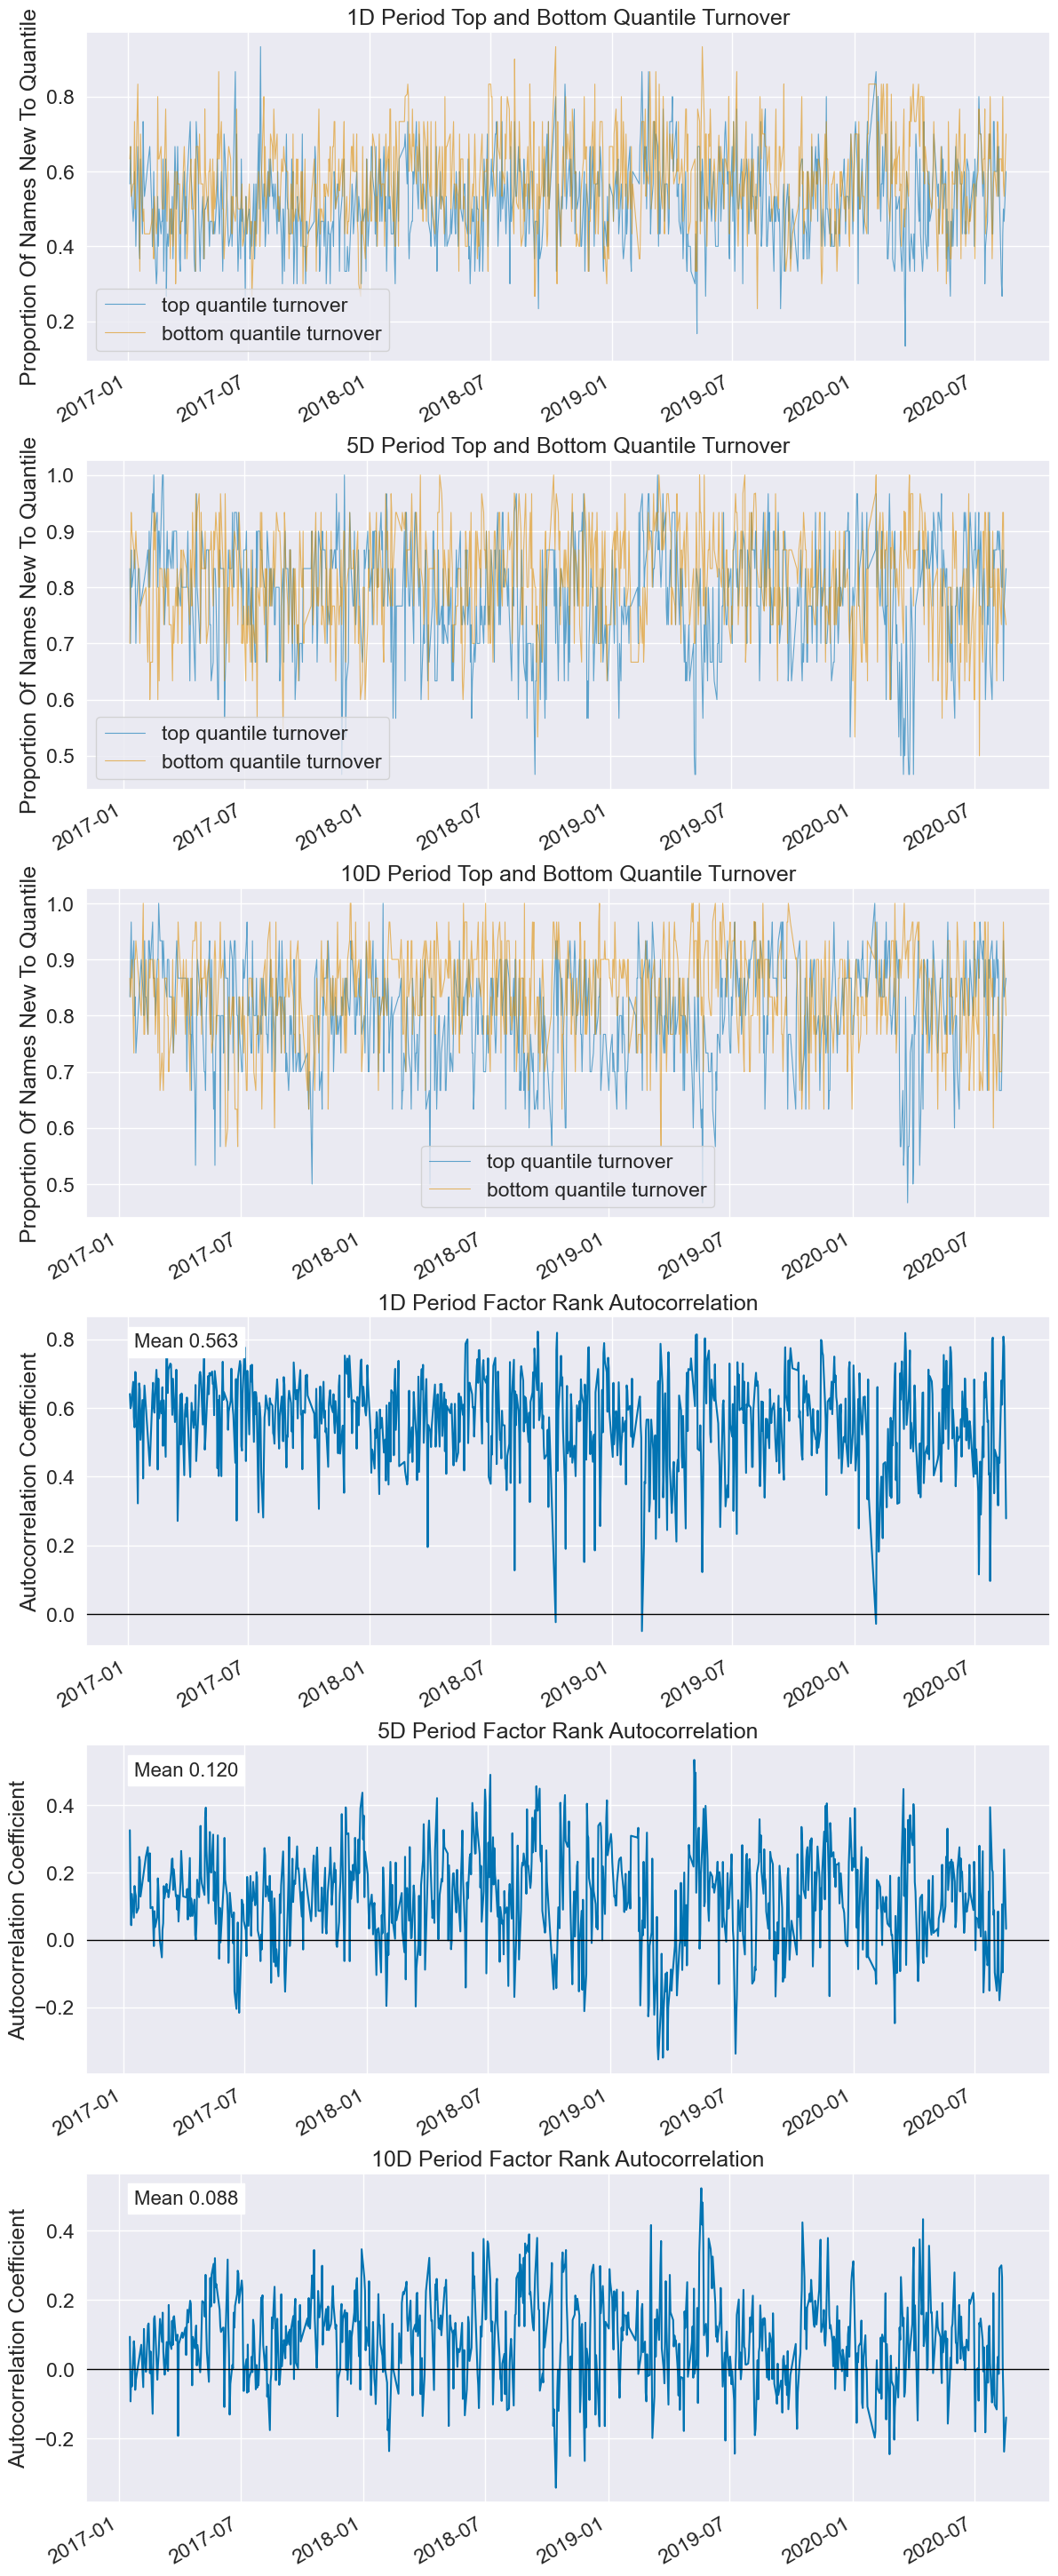

In [25]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [26]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [27]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [28]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [29]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [30]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [31]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-05-12 22:51:07 开始加载历史数据


100%|████████████████████████████████████████████████████████████████████████████████| 819/819 [00:08<00:00, 95.57it/s]

2026-05-12 22:51:15 部分合约历史数据为空：['600087.SSE', '601728.SSE', '600102.SSE', '600001.SSE', '600631.SSE', '600832.SSE', '605117.SSE', '601868.SSE', '300888.SZSE', '300866.SZSE', '600938.SSE', '601268.SSE', '000562.SZSE', '600941.SSE', '300896.SZSE', '601299.SSE', '688187.SSE', '600786.SSE', '300999.SZSE', '688271.SSE', '300957.SZSE', '688065.SSE', '605499.SSE', '001289.SZSE', '600357.SSE', '688303.SSE', '300979.SZSE', '000527.SZSE', '301269.SZSE', '300919.SZSE', '600591.SSE', '600905.SSE', '601825.SSE', '688223.SSE', '688041.SSE', '000024.SZSE', '601995.SSE', '601059.SSE']
2026-05-12 22:51:15 所有历史数据加载完成
2026-05-12 22:51:15 策略初始化完成
2026-05-12 22:51:15 开始回放历史数据


2026-05-12 22:51:21 历史数据回放结束
2026-05-12 22:51:21 开始计算逐日盯市盈亏
2026-05-12 22:51:22 逐日盯市盈亏计算完成
2026-05-12 22:51:22 开始计算策略统计指标
2026-05-12 22:51:22 ------------------------------
2026-05-12 22:51:22 首个交易日：  2017-01-03
2026-05-12 22:51:22 最后交易日：  2020-07-31
2026-05-12 22:51:22 总交易日：  871
2026-05-12 22:51:22 盈利交易日：  469
2026-05-12 22:51:22 亏损交易日：  401
2026-05-12 22:51:22 起始资金：  100,000,000.00
2026-05-12 22:51:22 结束资金：  274,793,958.21
2026-05-12 22:51:22 总收益率：  174.79%
2026-05-12 22:51:22 年化收益：  48.16%
2026-05-12 22:51:22 最大回撤:   -52,879,160.72
2026-05-12 22:51:22 百分比最大回撤: -21.79%
2026-05-12 22:51:22 最长回撤天数:   27
2026-05-12 22:51:22 总盈亏：  174,793,958.21
2026-05-12 22:51:22 总手续费：  19,232,228.74
2026-05-12 22:51:22 总成交金额：  25,669,513,256.30
2026-05-12 22:51:22 总成交笔数：  4566
2026-05-12 22:51:22 日均盈亏：  200,681.93
2026-05-12 22:51:22 日均手续费：  22,080.63
2026-05-12 22:51:22 日均成交金额：  29,471,312.58
2026-05-12 22:51:22 日均成交笔数：  5.2422502870264065
2026-05-12 22:51:22 日均收益率：  0.13%
2026-05-12 22:51:22 收益标准差：

D:\veighna_studio\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning:

urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!



In [32]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)